In [1]:
import torch
import os
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import sys
print(sys.executable)
import matplotlib.pyplot as plt
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")

/home/hoffmanp/diff_env/.venv/bin/python
Using GPU


device: cuda
gpu: NVIDIA L40S


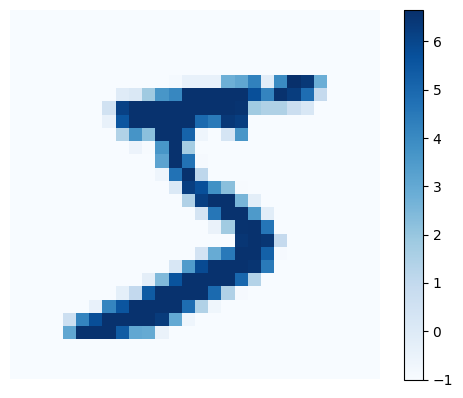

In [2]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if device.type == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))

# dataset location
DATA_DIR = "/home/hoffmanp/datasets/mnist"

# transform data to normalize (subtract mean and divide by std, both calculated on a population level)
# transforms.Compose() expects the arguments as a list.
# transforms.Normalize() expects meaan
transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize((0.1307,), (0.1307,))
    ])

# from torchvision import datasets which can be used to download and work with MNIST
# datasets 
train_ds = datasets.MNIST(root=DATA_DIR, train=True, download=True, transform=transform)
test_ds = datasets.MNIST(root=DATA_DIR, train=False, download=False, transform=transform)



# set data loaders
# for working on clusters, num_workers>0 speeds up data loading
# additionally, when working on cuda, setting pin_memory = True speeds transfer from CPU to GPU

num_workers = 4
pin_memory = (device.type == "cuda")

# loaders are python iterators that yield batches of data (img-label pairs)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,
                          num_workers=num_workers, pin_memory=pin_memory, persistent_workers=True)
test_loader  = DataLoader(test_ds, batch_size=512, shuffle=False,
                          num_workers=num_workers, pin_memory=pin_memory, persistent_workers=True)


# to view a tensor, move to CPU, detach from computational graph, 
# numpy can only work with tensors on the CPU
image_np = train_ds[0][0].cpu().detach().permute(1,2,0).numpy()

# Display the image
plt.imshow(image_np, cmap='Blues')
plt.colorbar()
plt.axis('off') # Optional: Turn off axis labels
plt.show()

imgs = [[], [], [], [], [], [], [], [], [], []]
for indx in range(len(train_ds)):
    img_label = train_ds[indx][1]
    imgs[img_label].append(train_ds[indx][0])


In [3]:
# compute per-class mean and covariance


# x.view() reshapes x without copying underlying data
# set the first dimension to x.size(0) = B and -1 lets python infer the second
def flatten_batch(x):
    # x: [B,1,28,28] -> [B,784]
    return x.view(x.size(0), -1)
@torch.no_grad()

def get_class_statistics(loader):
    d = 784
    num_classes = 10

    count = torch.zeros(d, dtype=torch.float64, requires_grad=False)
    sums_x = torch.zeros((num_classes, d), dtype=torch.float64, requires_grad=False)
    sums_xx = torch.zeros((num_classes, d,d), dtype=torch.float64, requires_grad=False)


def compute_class_stats(loader, device_for_batches="cpu", dtype=torch.float64):
    """
    Returns:
      mu[c]: [784] float64
      cov[c]: [784,784] float64 (unbiased sample covariance)
      n[c]: int
    """
    d = 28*28
    num_classes = 10

    n = torch.zeros(num_classes, dtype=torch.long)
    sum_x = torch.zeros((num_classes, d), dtype=dtype)
    sum_xx = torch.zeros((num_classes, d, d), dtype=dtype)

    # xb is batch of images
    # yb is batch of ground truth labels
    
    for xb, yb in loader:
        xb = xb.to(device_for_batches, non_blocking=True)
        yb = yb.to(device_for_batches, non_blocking=True)

        X = flatten_batch(xb).to(dtype)  # [B,784]
        y = yb

        for c in range(num_classes):
            mask = (y == c)
            if mask.any():
                Xc = X[mask]                       # [nc,784]
                n_c = Xc.size(0)
                n[c] += n_c
                sum_x[c] += Xc.sum(dim=0)
                sum_xx[c] += Xc.T @ Xc

    mu = torch.zeros_like(sum_x)
    cov = torch.zeros_like(sum_xx)

    for c in range(num_classes):
        if n[c] < 2:
            continue
        mu[c] = sum_x[c] / n[c].item()

        # population second moment E[xx^T]
        Exx = sum_xx[c] / n[c].item()
        # biased covariance 
        Sigma_bias = Exx - torch.outer(mu[c], mu[c])

        # unbiased sample covariance: multiply by n/(n-1)
        cov[c] = Sigma_bias * (n[c].item() / (n[c].item() - 1))

    return mu, cov, n

mu, cov, n = compute_class_stats(train_loader, device_for_batches="cpu")
print("counts:", n.tolist())


counts: [5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]


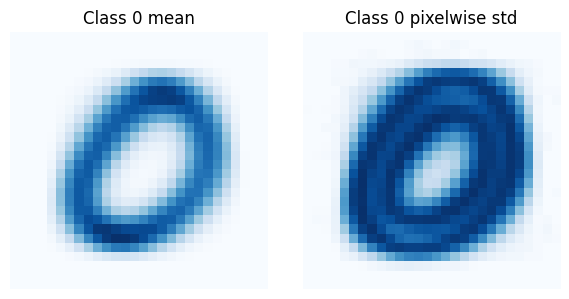

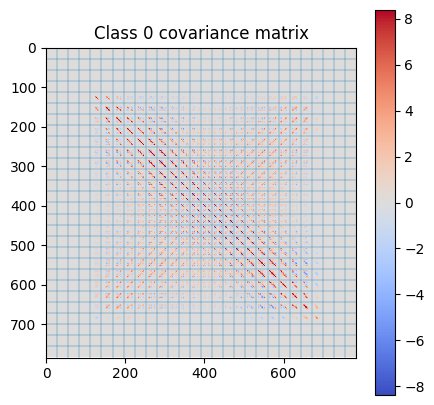

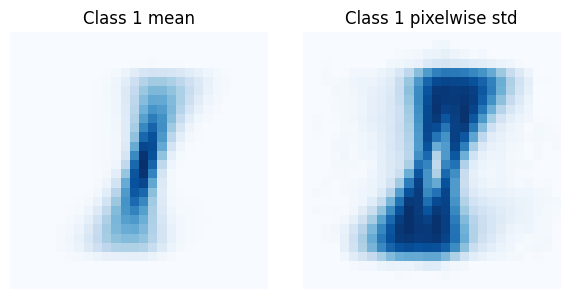

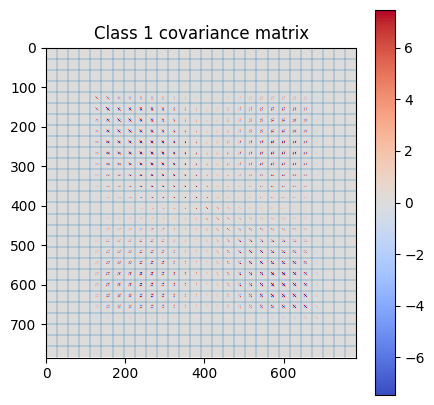

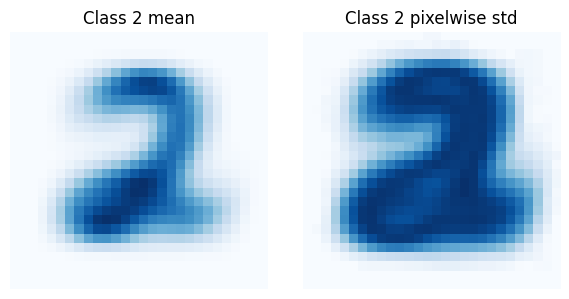

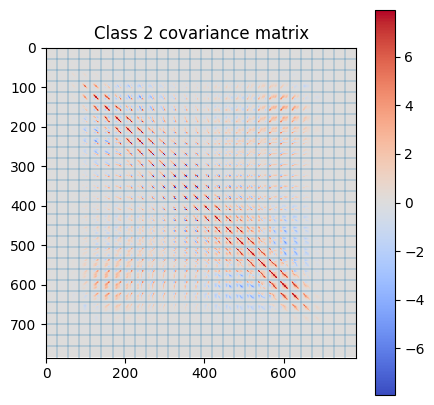

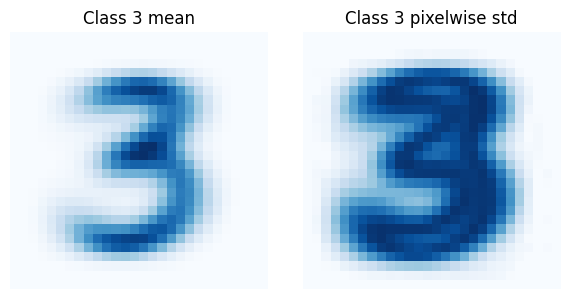

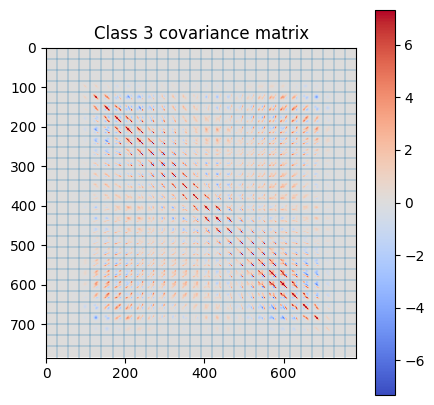

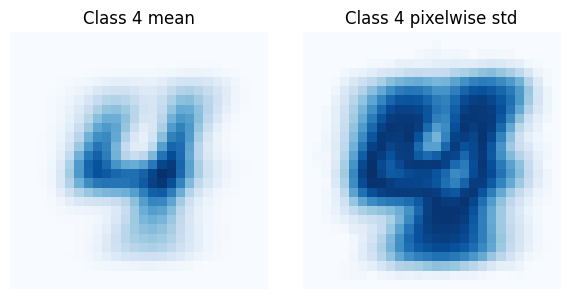

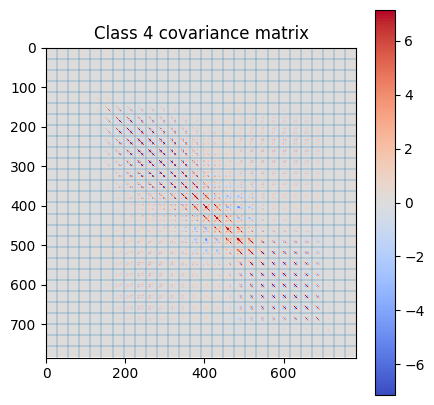

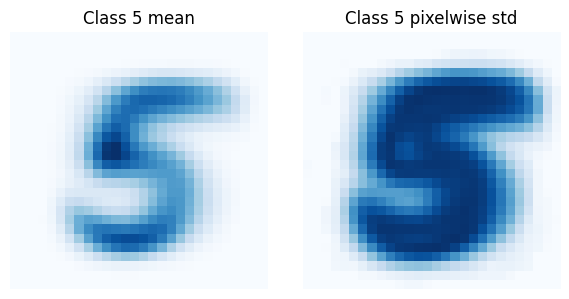

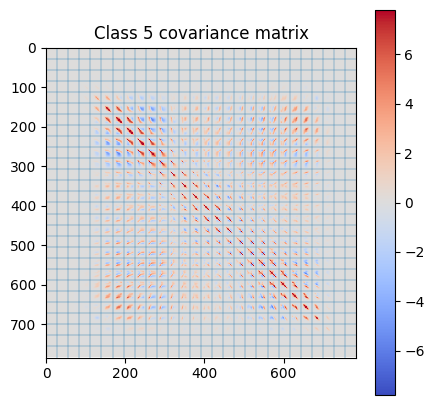

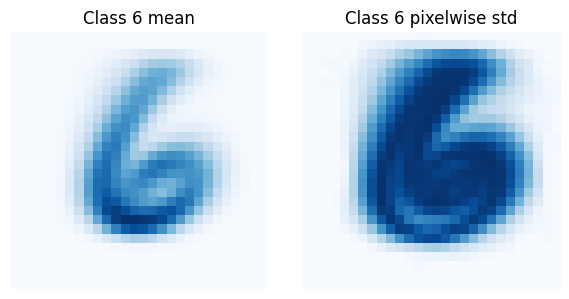

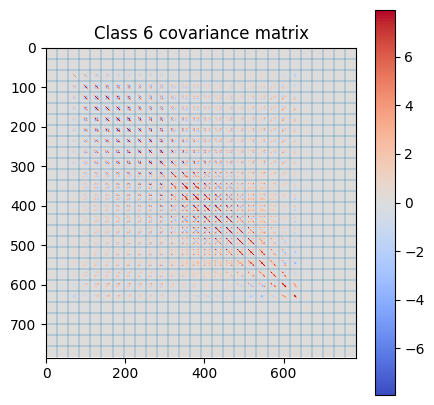

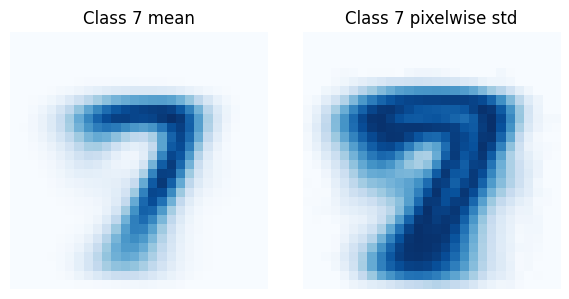

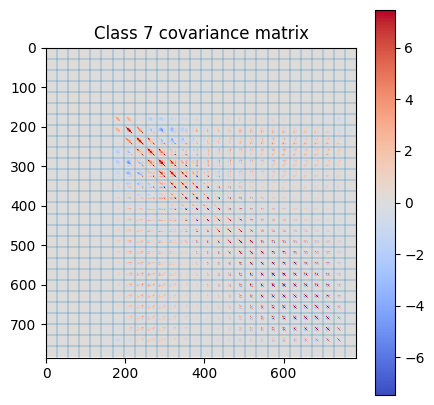

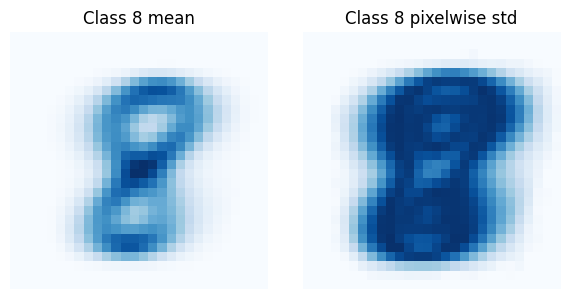

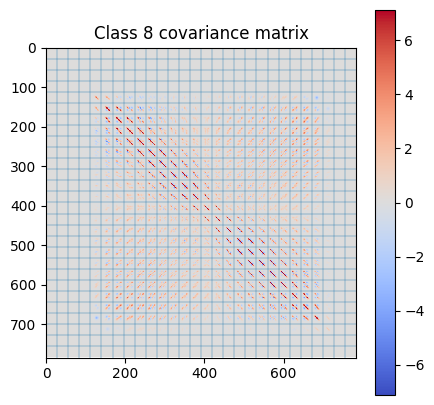

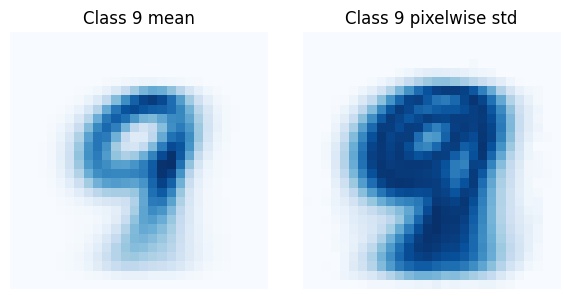

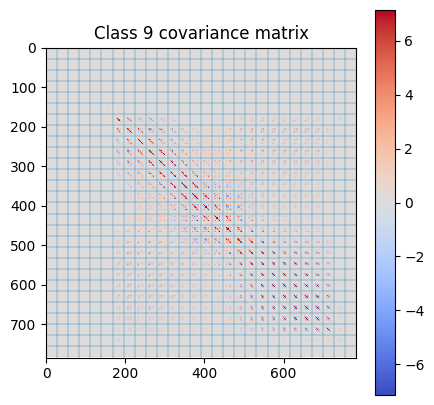

In [4]:
# plot mean and pixelwise std for each class

def show_mean_and_std(mu_c, cov_c, title=""):
    mean_img = mu_c.view(28,28).cpu()
    std_img = torch.sqrt(torch.clamp(torch.diag(cov_c), min=0)).view(28,28).cpu()

    fig, axs = plt.subplots(1,2, figsize=(6,3))
    axs[0].imshow(mean_img, cmap="Blues")
    axs[0].set_title(f"{title} mean")
    axs[0].axis("off")

    axs[1].imshow(std_img, cmap="Blues")
    axs[1].set_title(f"{title} pixelwise std")
    axs[1].axis("off")
    plt.tight_layout()
    plt.show()

    # plt.figure(figsize=(5,5))
    # plt.imshow(cov_c.cpu(), aspect="auto")
    # plt.title("Covariance matrix")
    # plt.colorbar()
    # plt.show()

    C = cov_c.cpu()
    v = float(C.abs().quantile(0.999))  # robust scale; avoids a few extremes dominating
    plt.figure(figsize=(5,5))
    plt.imshow(C, cmap="coolwarm", vmin=-v, vmax=v, interpolation="nearest")
    for k in range(0, 784, 28):
        plt.axhline(k-0.5, linewidth=0.3)
        plt.axvline(k-0.5, linewidth=0.3)
    plt.title(f"{title} covariance matrix")
    plt.colorbar()
    plt.show()


for c in range(10):
    show_mean_and_std(mu[c], cov[c], title=f"Class {c}")


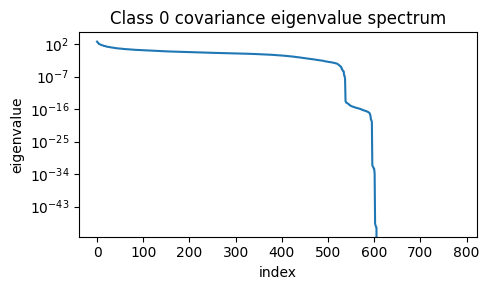

class 0: top/median eigenvalue ratio = 5790.75


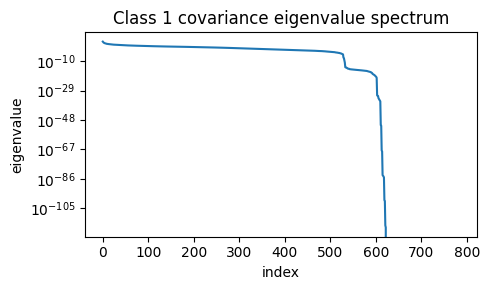

class 1: top/median eigenvalue ratio = 128683.42


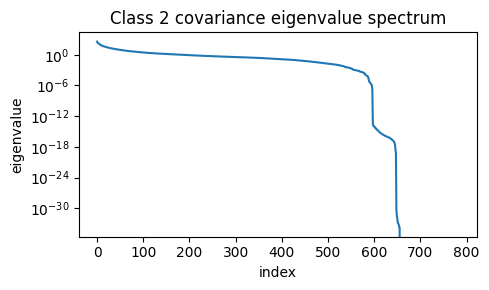

class 2: top/median eigenvalue ratio = 2389.66


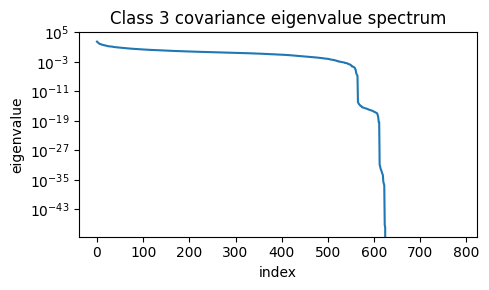

class 3: top/median eigenvalue ratio = 3094.76


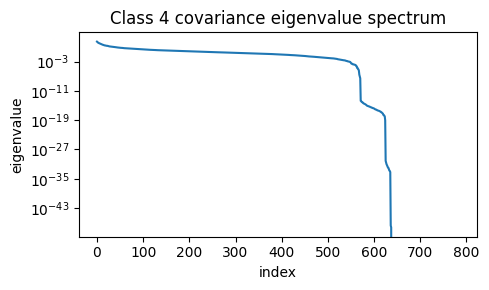

class 4: top/median eigenvalue ratio = 3051.59


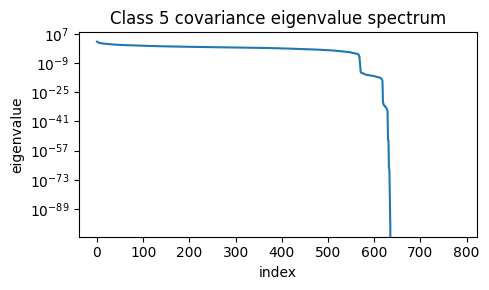

class 5: top/median eigenvalue ratio = 4549.74


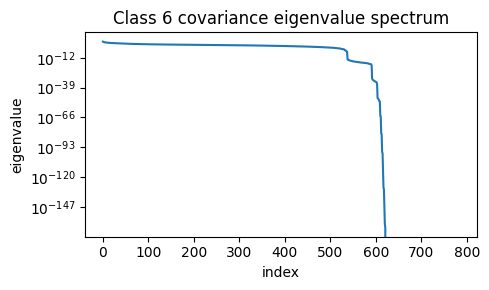

class 6: top/median eigenvalue ratio = 8344.45


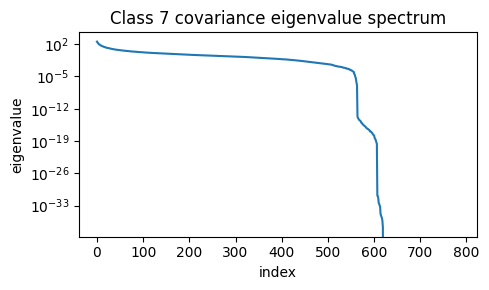

class 7: top/median eigenvalue ratio = 5763.91


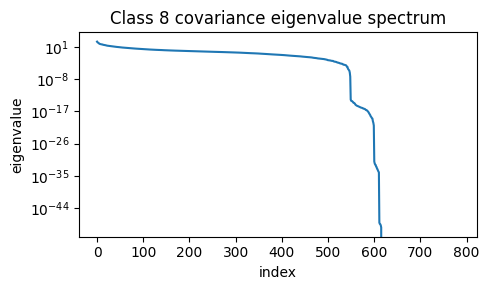

class 8: top/median eigenvalue ratio = 4590.00


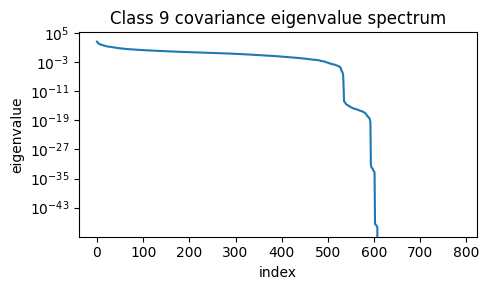

class 9: top/median eigenvalue ratio = 10816.21


In [5]:
# eigenvalue spectrum of Cov[class] covariance
# if a class were close to isotropic Gaussian, eigenvalues would be relatively flat
# a large top/median ratio means non-isotropic


def cov_eigenspectrum(cov_c):
    # PSD
    evals = torch.linalg.eigvalsh(cov_c).cpu()
    evals = torch.clamp(evals, min=0)
    return evals

for c in range(10):
    evals = cov_eigenspectrum(cov[c])
    plt.figure(figsize=(5,3))
    plt.plot(evals.numpy()[::-1])
    plt.yscale("log")
    plt.title(f"Class {c} covariance eigenvalue spectrum")
    plt.xlabel("index")
    plt.ylabel("eigenvalue")
    plt.tight_layout()
    plt.show()

    print(f"class {c}: top/median eigenvalue ratio = {float(evals.max() / evals.median()):.2f}")



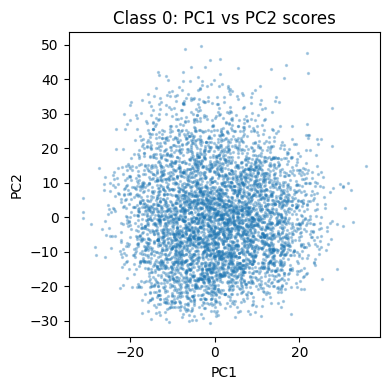

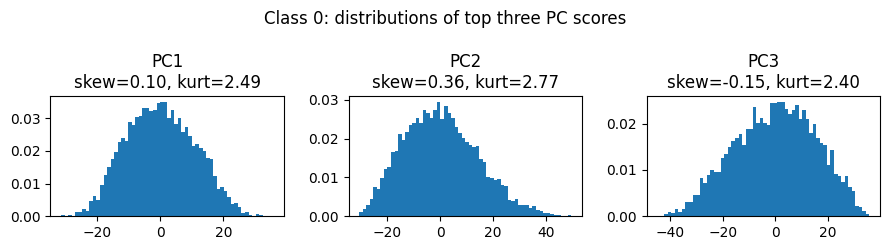

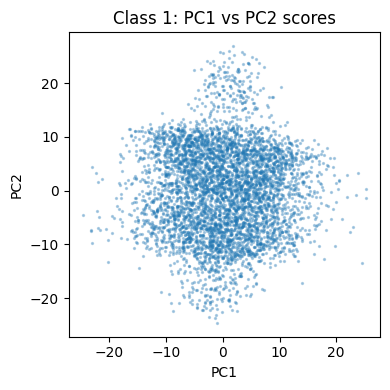

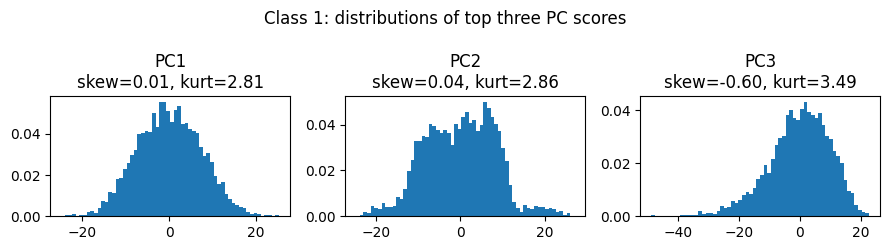

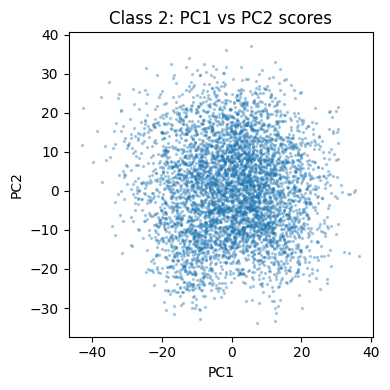

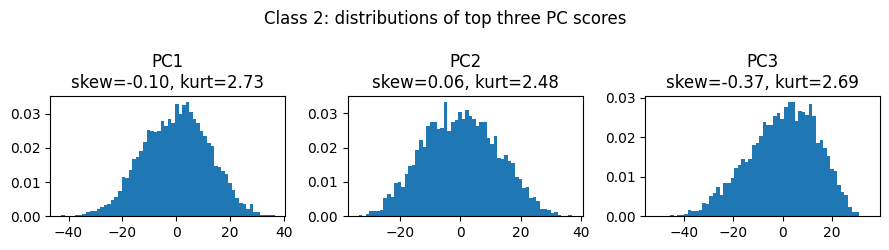

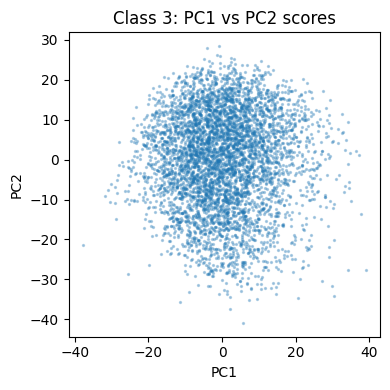

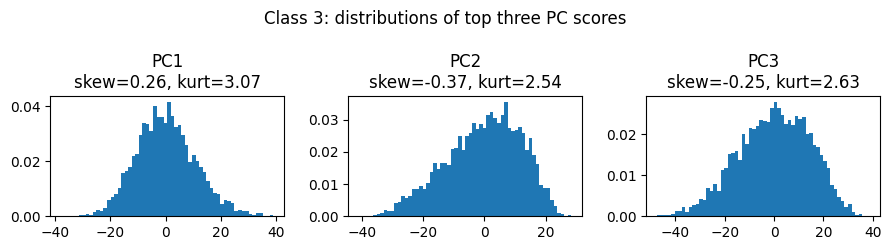

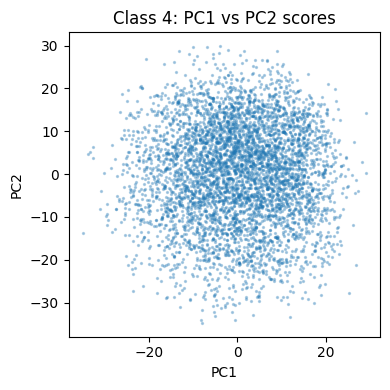

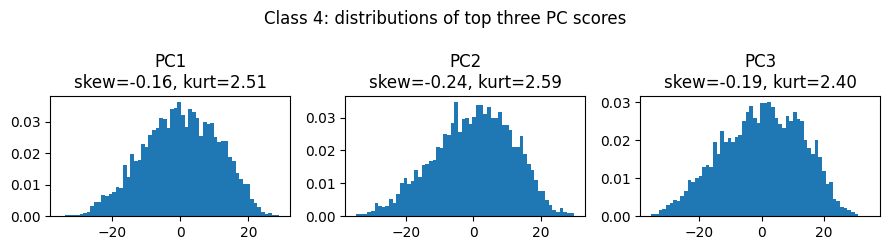

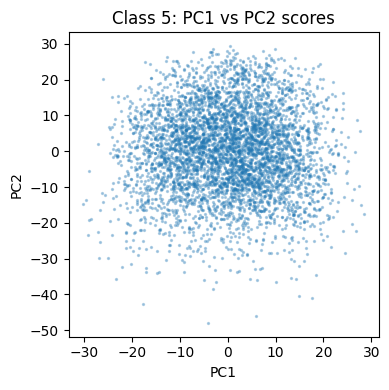

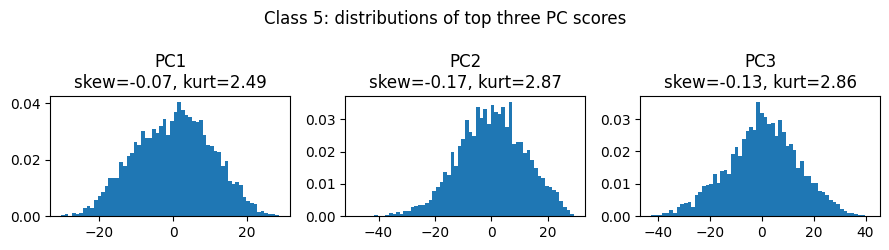

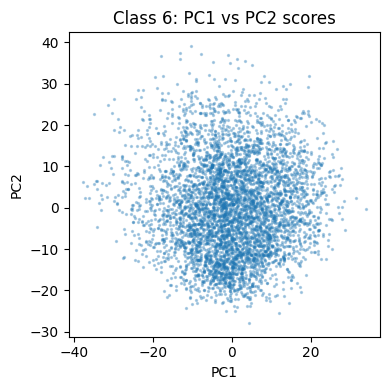

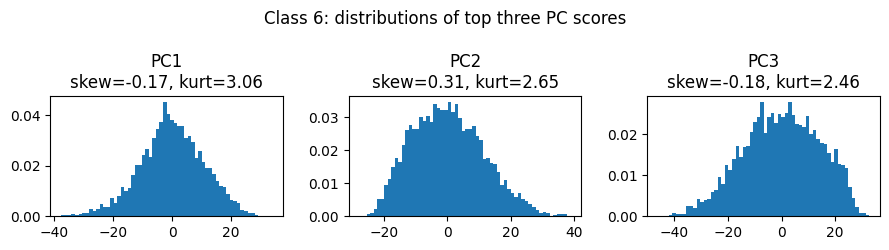

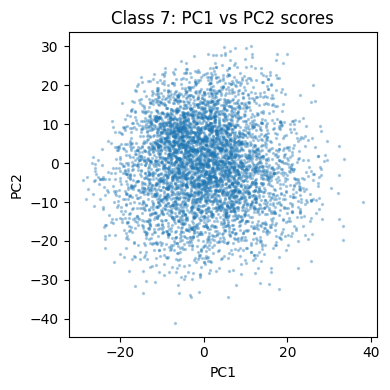

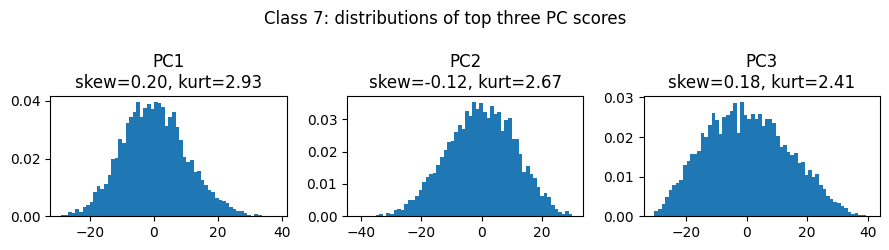

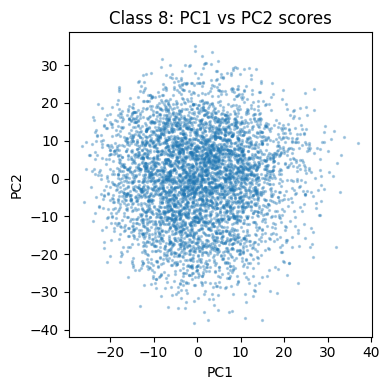

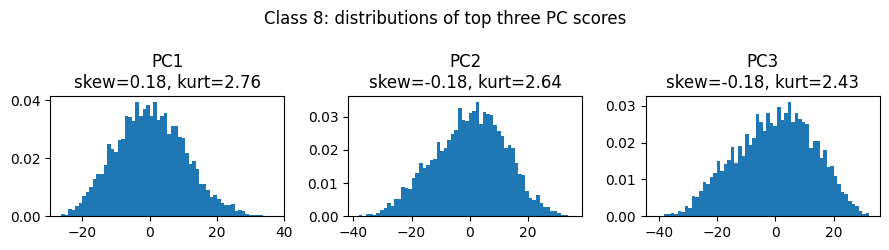

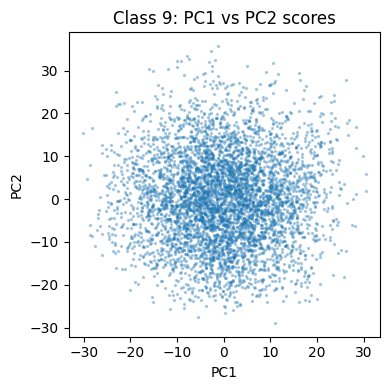

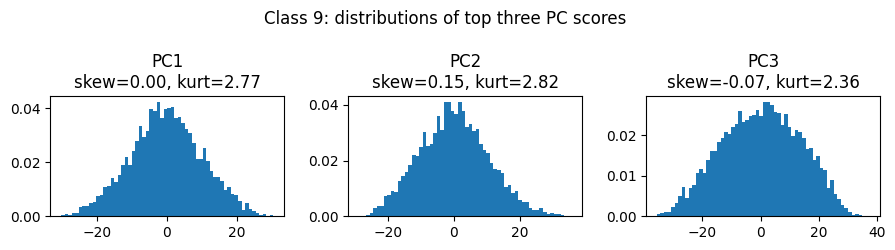

In [6]:
# PCA score scatter and histogram of top 3 principal components:
#   compute top-3 PCs from the class covariance 
#   project samples using z_i = V^T x_i to get projection of data onto eigenvectors
#   use the top three scores z_i,1, z_i,2, z_i,3 for analysis
#   a Gaussian has have PC scores that are close to normal (skew ~ 0, kurt ~ 3)

@torch.no_grad()
def sample_per_class(dataset, M=5000):
    # dataset returns (x,y) already transformed
    buckets = {c: [] for c in range(10)}
    for i in range(len(dataset)):
        x, y = dataset[i]
        y = int(y)
        if len(buckets[y]) < M:
            buckets[y].append(x)
        if all(len(buckets[c]) >= M for c in range(10)):
            break
    Xc = {}
    for c in range(10):
        X = torch.stack(buckets[c], dim=0)   # [M,1,28,28]
        Xc[c] = X.view(X.size(0), -1).to(torch.float64)  # [M,784]
    return Xc

def skew_kurtosis(z):
    # z: [n] tensor
    z = z - z.mean()
    m2 = (z**2).mean()
    m3 = (z**3).mean()
    m4 = (z**4).mean()
    skew = m3 / (m2.sqrt()**3 + 1e-12)
    kurt = m4 / (m2**2 + 1e-12)  # normal => 3
    return float(skew), float(kurt)

Xc = sample_per_class(train_ds, M=5000)

def pca_from_cov(cov_c, k=10):
    # cov_c: [784,784]
    evals, evecs = torch.linalg.eigh(cov_c)  # ascending
    # take top-k
    U = evecs[:, -k:]                        # [784,k]
    S = evals[-k:]                           # [k]
    return U, S

for c in range(10):
    X = Xc[c]                                 # [M,784]
    X_center = X - mu[c].unsqueeze(0)

    U, S = pca_from_cov(cov[c], k=5)
    Z = X_center @ U                          # [M,5] PC scores

    # Scatter of first two PCs
    plt.figure(figsize=(4,4))
    plt.scatter(Z[:,0].cpu(), Z[:,1].cpu(), s=2, alpha=0.3)
    plt.title(f"Class {c}: PC1 vs PC2 scores")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

    # Histograms + skew/kurt for top PCs
    fig, axs = plt.subplots(1,3, figsize=(9,2.5))
    for j in range(3):
        zj = Z[:,j].cpu()
        axs[j].hist(zj.numpy(), bins=60, density=True)
        sk, ku = skew_kurtosis(zj)
        axs[j].set_title(f"PC{j+1}\nskew={sk:.2f}, kurt={ku:.2f}")
    plt.suptitle(f"Class {c}: distributions of top three PC scores")
    plt.tight_layout()
    plt.show()


class 0: d^2 mean=20.00 (target 20), var=39.50 (target 40)


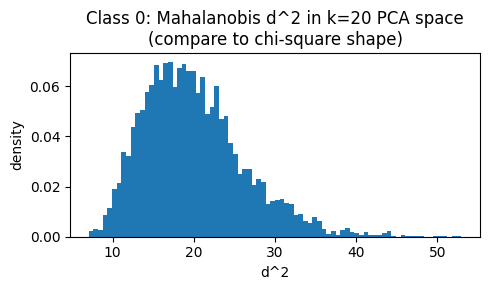

class 1: d^2 mean=20.00 (target 20), var=153.60 (target 40)


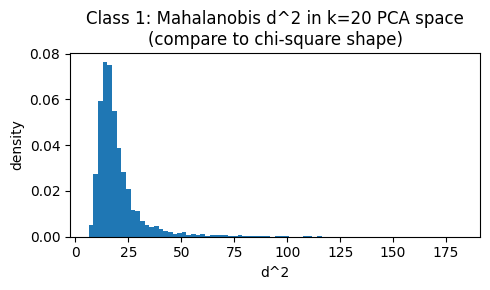

class 2: d^2 mean=20.00 (target 20), var=29.09 (target 40)


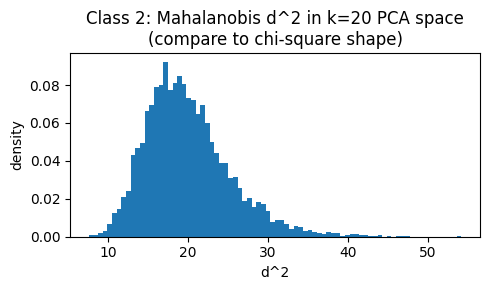

class 3: d^2 mean=20.00 (target 20), var=37.20 (target 40)


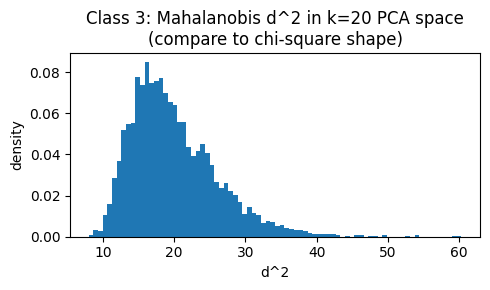

class 4: d^2 mean=20.00 (target 20), var=39.11 (target 40)


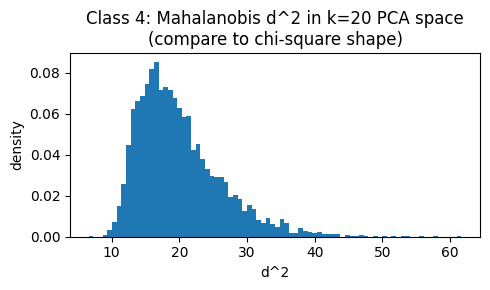

class 5: d^2 mean=20.00 (target 20), var=36.36 (target 40)


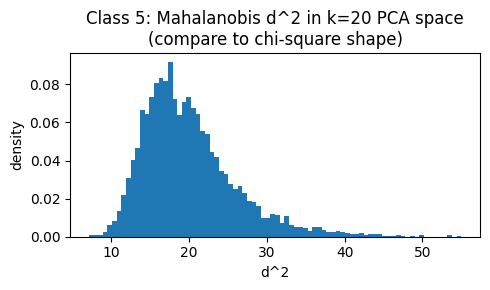

class 6: d^2 mean=20.00 (target 20), var=45.65 (target 40)


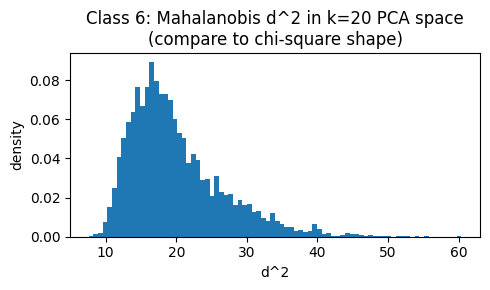

class 7: d^2 mean=20.00 (target 20), var=60.72 (target 40)


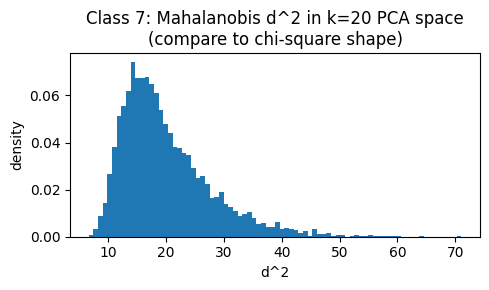

class 8: d^2 mean=20.00 (target 20), var=35.66 (target 40)


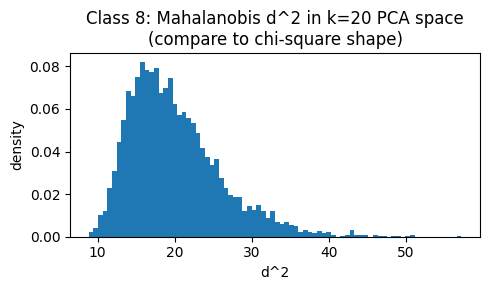

class 9: d^2 mean=20.00 (target 20), var=53.42 (target 40)


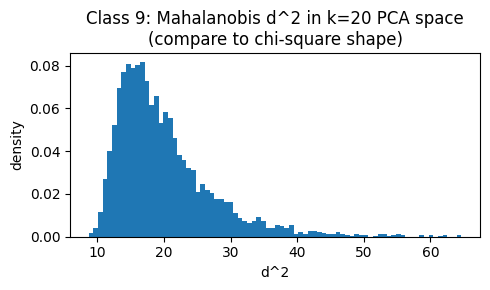

In [7]:
# Mahalanobis distance check in reduced dimension k
#   distance look like chi^2_k if the centered scores z_i = U^T x_i are gaussian


@torch.no_grad()
def mahalanobis_sq(Z):
    # Z: [n,k]
    Zc = Z - Z.mean(dim=0, keepdim=True)
    k = Z.size(1)
    # covariance in k-d
    C = (Zc.T @ Zc) / (Zc.size(0) - 1)
    # small ridge for numerical stability
    ridge = 1e-6 * torch.eye(k, dtype=Z.dtype)
    Ci = torch.linalg.inv(C + ridge)
    d2 = torch.sum((Zc @ Ci) * Zc, dim=1)
    return d2

for c in range(10):
    X = Xc[c]
    X_center = X - mu[c].unsqueeze(0)
    U, S = pca_from_cov(cov[c], k=20)
    Z = X_center @ U               # [M,20]
    d2 = mahalanobis_sq(Z).cpu()

    k = Z.size(1)
    print(f"class {c}: d^2 mean={d2.mean():.2f} (target {k}), var={d2.var(unbiased=True):.2f} (target {2*k})")

    plt.figure(figsize=(5,3))
    plt.hist(d2.numpy(), bins=80, density=True)
    plt.title(f"Class {c}: Mahalanobis d^2 in k={k} PCA space\n(compare to chi-square shape)")
    plt.xlabel("d^2")
    plt.ylabel("density")
    plt.tight_layout()
    plt.show()


In [8]:
# 3a — Fit a shared isotropic covariance I and evaluate
#    First find the sigma0^2 using pooled within-class isotropic fit


d = 28*28
num = torch.zeros((d,d), dtype=torch.float64)
den = 0
for c in range(10):
    if n[c] >= 2:
        num += (n[c].item() - 1) * cov[c]
        den += (n[c].item() - 1)
Sigma_pooled = num / den
sigma0_sq = torch.trace(Sigma_pooled).item() / d
print("sigma0^2 (pooled within-class isotropic fit):", sigma0_sq)


sigma0^2 (pooled within-class isotropic fit): 3.1214979998034393


In [ ]:
#3b  - How good is sigma_0^2 I for each class?
# thie calculates the relative Frobenius error = ||Sigma_c - sigma_0 I||_F / ||Sigma_c||_F
# Contained in [0,1], and want to be close to 0.

I = torch.eye(d, dtype=torch.float64)

for c in range(10):
    if n[c] < 2:
        continue
    rel_frob = torch.linalg.norm(cov[c] - sigma0_sq * I) / torch.linalg.norm(cov[c])
    evals = cov_eigenspectrum(cov[c])
    lam_max = float(evals.max())
    lam_med = float(evals.median())
    lam_min = float(evals[0])

    print(
        f"class {c}: "
        f"rel_Frob_err={float(rel_frob):.3f}, "
        f"lam_max/s0={lam_max/sigma0_sq:.1f}, "
        f"lam_med/s0={lam_med/sigma0_sq:.2f}, "
        f"lam_min/s0={lam_min/sigma0_sq:.2f}"
    )


class 0: rel_Frob_err=0.990, lam_max/s0=163.6, lam_med/s0=0.03, lam_min/s0=0.00
class 1: rel_Frob_err=0.999, lam_max/s0=147.7, lam_med/s0=0.00, lam_min/s0=0.00
class 2: rel_Frob_err=0.984, lam_max/s0=114.5, lam_med/s0=0.05, lam_min/s0=0.00
class 3: rel_Frob_err=0.985, lam_max/s0=105.1, lam_med/s0=0.03, lam_min/s0=0.00
class 4: rel_Frob_err=0.985, lam_max/s0=91.5, lam_med/s0=0.03, lam_min/s0=0.00
class 5: rel_Frob_err=0.988, lam_max/s0=149.3, lam_med/s0=0.03, lam_min/s0=0.00
class 6: rel_Frob_err=0.989, lam_max/s0=140.0, lam_med/s0=0.02, lam_min/s0=0.00
class 7: rel_Frob_err=0.989, lam_max/s0=113.0, lam_med/s0=0.02, lam_min/s0=0.00
class 8: rel_Frob_err=0.983, lam_max/s0=105.7, lam_med/s0=0.02, lam_min/s0=0.00
class 9: rel_Frob_err=0.988, lam_max/s0=116.3, lam_med/s0=0.01, lam_min/s0=0.00


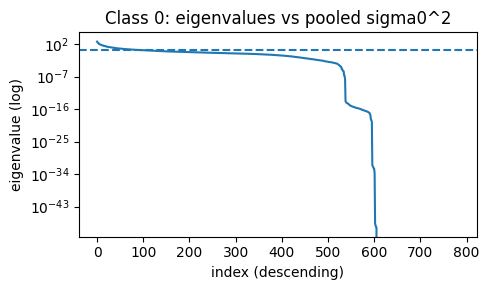

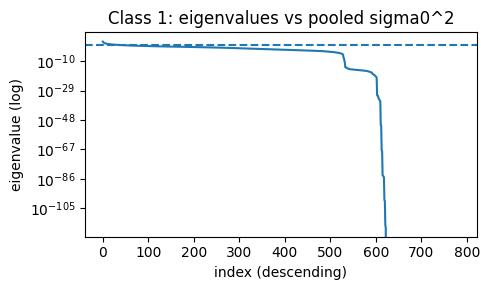

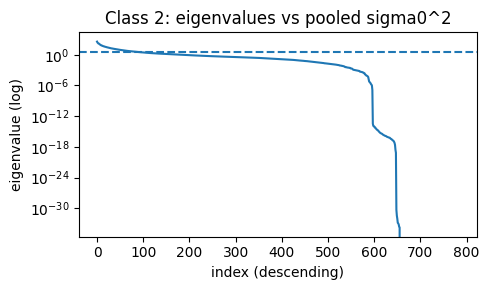

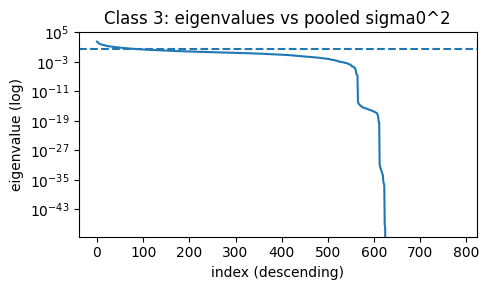

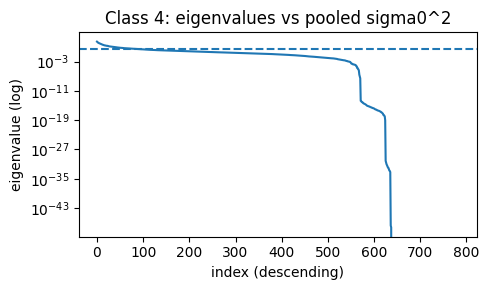

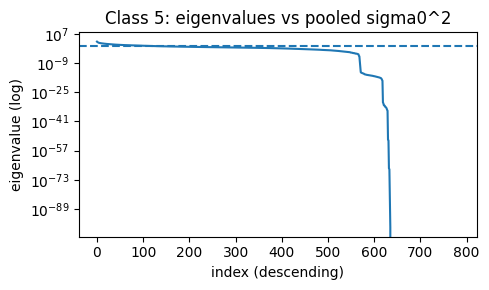

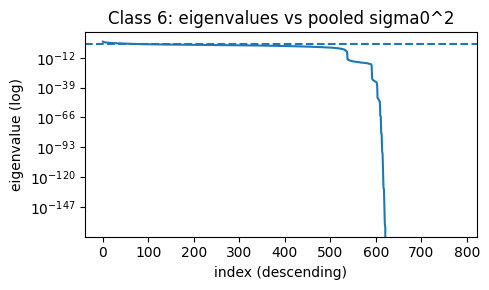

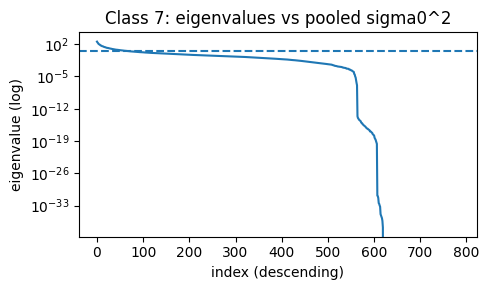

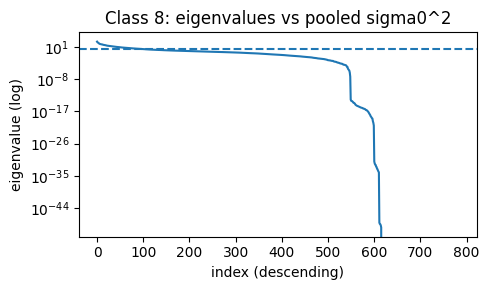

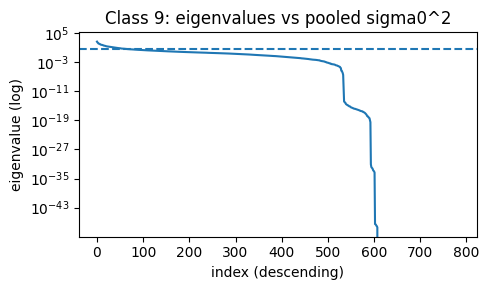

In [10]:
# 3c - visualization eigenvalues vs sigma_0^2
#   If the dashed line is nowhere near the curve for most indices (it won’t be), isotropic is a poor covariance model

for c in range(10):
    evals = cov_eigenspectrum(cov[c]).numpy()[::-1]  # descending
    plt.figure(figsize=(5,3))
    plt.plot(evals)
    plt.axhline(sigma0_sq, linestyle="--")
    plt.yscale("log")
    plt.title(f"Class {c}: eigenvalues vs pooled sigma0^2")
    plt.xlabel("index (descending)")
    plt.ylabel("eigenvalue (log)")
    plt.tight_layout()
    plt.show()
